## ***Lung Cancer risk Prediction : Unified ML Model Comparison***

In [2]:
### SET UP ###____________________

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, auc,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded. SEED =", SEED)

#f-t transformer
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

# Install the missing library
!pip install rtdl-revisiting-models

from rtdl_revisiting_models import FTTransformer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

Libraries loaded. SEED = 42


In [3]:
### LOAD DATA ###________________________
from google.colab import files
import io
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Assuming the uploaded file is 'Lung_Cancer_Dataset.csv'
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

df["PULMONARY_DISEASE"] = df["PULMONARY_DISEASE"].map({"YES": 1, "NO": 0})

print("\nClass distribution:")
print(df["PULMONARY_DISEASE"].value_counts())
print(df["PULMONARY_DISEASE"].value_counts(normalize=True).round(4))

CONTINUOUS_FEATURES = ["AGE", "ENERGY_LEVEL", "OXYGEN_SATURATION"]
BINARY_FEATURES = [c for c in df.columns if c not in CONTINUOUS_FEATURES + ["PULMONARY_DISEASE"]]
print(f"\n{len(CONTINUOUS_FEATURES)} continuous features, {len(BINARY_FEATURES)} binary features")


Saving Lung Cancer Dataset.csv to Lung Cancer Dataset.csv
User uploaded file "Lung Cancer Dataset.csv" with length 352359 bytes
Shape: (5000, 18)
Missing values: 0
Duplicate rows: 0

Class distribution:
PULMONARY_DISEASE
0    2963
1    2037
Name: count, dtype: int64
PULMONARY_DISEASE
0    0.5926
1    0.4074
Name: proportion, dtype: float64

3 continuous features, 14 binary features


In [4]:
### 2. Canonical Train / Validation / Test Split (70 / 15 / 15, SEED = 42) ### ____________________________________

X = df.drop(columns=["PULMONARY_DISEASE"])
y = df["PULMONARY_DISEASE"]

# Step 1: carve off 15% test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Step 2: split remaining 85% into 70% train / 15% val  (0.15/0.85 = 0.1765)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=SEED, stratify=y_temp
)

print("Split sizes:")
print(f"  Train : {len(X_train):>5} rows ({len(X_train)/len(df):.1%})")
print(f"  Val   : {len(X_val):>5} rows ({len(X_val)/len(df):.1%})")
print(f"  Test  : {len(X_test):>5} rows ({len(X_test)/len(df):.1%})")

print("\nPositive rate per split:")
print(f"  Train: {y_train.mean():.3f}  Val: {y_val.mean():.3f}  Test: {y_test.mean():.3f}")



Split sizes:
  Train :  3500 rows (70.0%)
  Val   :   750 rows (15.0%)
  Test  :   750 rows (15.0%)

Positive rate per split:
  Train: 0.407  Val: 0.407  Test: 0.408


In [5]:
### PREPROCESSING ###__________________

scaler = StandardScaler()
scaler.fit(X_train[CONTINUOUS_FEATURES])

def scale_continuous(frame):
    out = frame.copy()
    out[CONTINUOUS_FEATURES] = scaler.transform(frame[CONTINUOUS_FEATURES])
    return out

X_train_scaled = scale_continuous(X_train)
X_val_scaled   = scale_continuous(X_val)
X_test_scaled  = scale_continuous(X_test)

print("Scaler fit on X_train only. Scaled matrices created for Logistic Regression.")


Scaler fit on X_train only. Scaled matrices created for Logistic Regression.


In [6]:
### Shared Baseline (DummyClassifier) ###____________________


dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)

dummy_pred_test = dummy.predict(X_test)
dummy_prob_test = dummy.predict_proba(X_test)[:, 1]

baseline_summary = {
    "Model": "Baseline (DummyClassifier)",
    "Test_Recall": recall_score(y_test, dummy_pred_test, zero_division=0),
    "Test_Precision": precision_score(y_test, dummy_pred_test, zero_division=0),
    "Test_F1": f1_score(y_test, dummy_pred_test, zero_division=0),
    "Test_ROC_AUC": roc_auc_score(y_test, dummy_prob_test) if len(set(dummy_prob_test)) > 1 else 0.5,
    "Test_PR_AUC": average_precision_score(y_test, dummy_prob_test) if len(set(dummy_prob_test)) > 1 else y_test.mean(),
}
print("Baseline (No-Skill) performance on test set:")
for k, v in baseline_summary.items():
    print(f"  {k}: {v}")
print(f"\nPR-AUC no-skill reference = test-set prevalence = {y_test.mean():.3f}")



Baseline (No-Skill) performance on test set:
  Model: Baseline (DummyClassifier)
  Test_Recall: 0.0
  Test_Precision: 0.0
  Test_F1: 0.0
  Test_ROC_AUC: 0.5
  Test_PR_AUC: 0.408

PR-AUC no-skill reference = test-set prevalence = 0.408


In [7]:
### Shared Threshold - Selection Utility ###___________________________


TARGET_RECALL = 0.95
THRESH_GRID = np.arange(0.05, 0.96, 0.01)

def sweep_thresholds(y_true_val, y_prob_val):
    rows = []
    for t in THRESH_GRID:
        pred = (y_prob_val >= t).astype(int)
        rows.append({
            "Threshold": round(t, 2),
            "Recall": recall_score(y_true_val, pred, zero_division=0),
            "Precision": precision_score(y_true_val, pred, zero_division=0),
            "F1": f1_score(y_true_val, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

def select_threshold(sweep_df, target_recall=TARGET_RECALL):
    qualifying = sweep_df[sweep_df["Recall"] >= target_recall]
    if len(qualifying) > 0:
        best_row = qualifying.loc[qualifying["Precision"].idxmax()]
        return float(best_row["Threshold"]), True
    else:
        best_row = sweep_df.loc[sweep_df["Recall"].idxmax()]
        return float(best_row["Threshold"]), False

def plot_sweep(sweep_df, selected_threshold, model_name):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(sweep_df["Threshold"], sweep_df["Recall"], label="Recall", color="#d62728", lw=2)
    ax.plot(sweep_df["Threshold"], sweep_df["Precision"], label="Precision", color="#1f77b4", lw=2)
    ax.plot(sweep_df["Threshold"], sweep_df["F1"], label="F1", color="#2ca02c", lw=2, linestyle="--")
    ax.axhline(TARGET_RECALL, color="gray", linestyle=":", label=f"Target Recall = {TARGET_RECALL}")
    ax.axvline(selected_threshold, color="black", linestyle="--", label=f"Selected t = {selected_threshold}")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"{model_name}: Threshold Sweep (Validation Set)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

print("Threshold-selection utilities defined.")


Threshold-selection utilities defined.


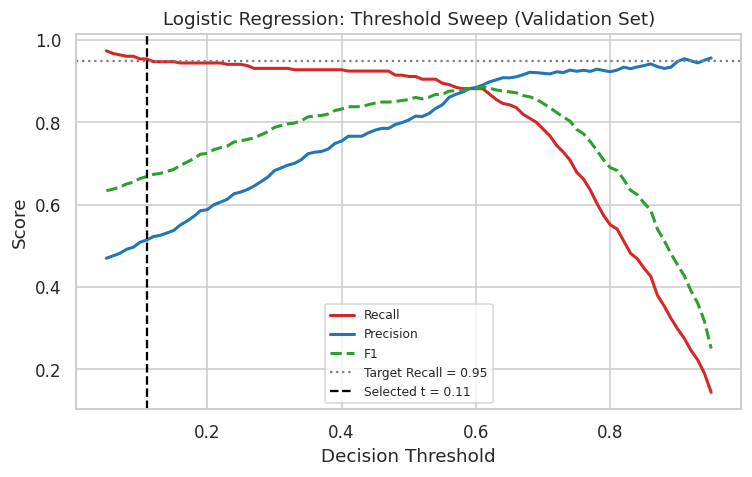

Selected threshold: 0.11  (target recall met on val: True)


In [8]:
### Model1- Logistic Regression ###_____________________________


log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)
log_reg.fit(X_train_scaled, y_train)

lr_val_prob = log_reg.predict_proba(X_val_scaled)[:, 1]
lr_sweep = sweep_thresholds(y_val, lr_val_prob)
lr_threshold, lr_met_target = select_threshold(lr_sweep)
plot_sweep(lr_sweep, lr_threshold, "Logistic Regression")
print(f"Selected threshold: {lr_threshold}  (target recall met on val: {lr_met_target})")



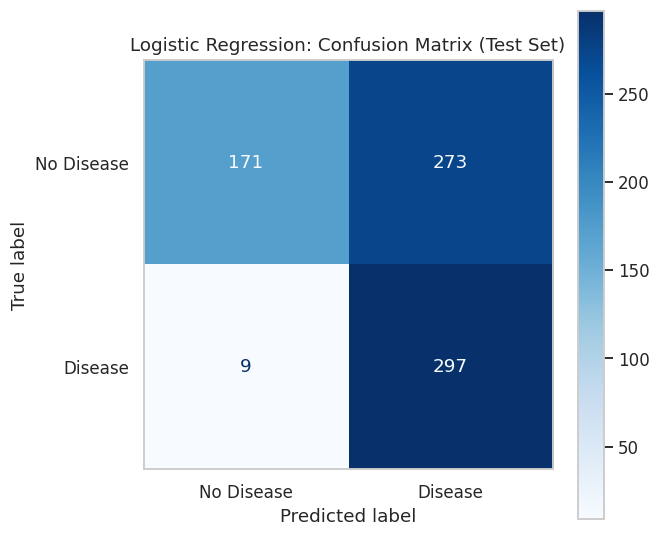

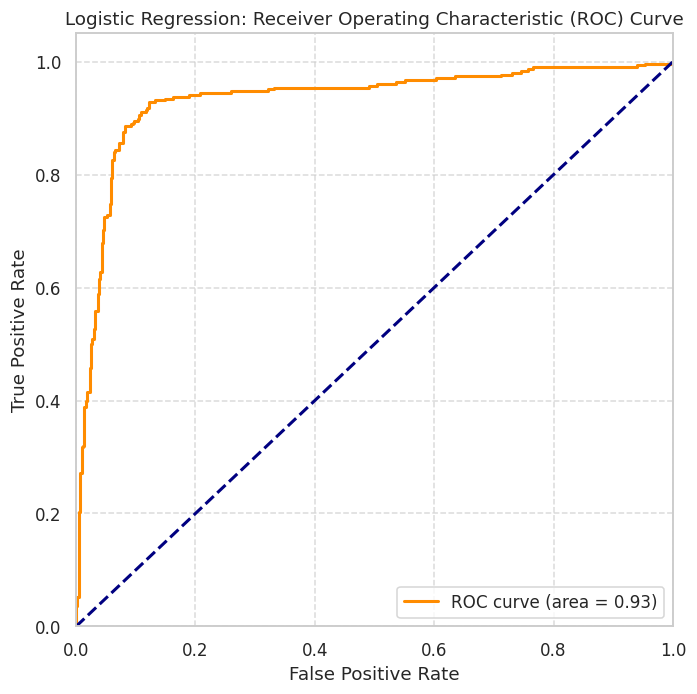

Logistic Regression - Classification Report (Test Set):

              precision    recall  f1-score   support

  No Disease       0.95      0.39      0.55       444
     Disease       0.52      0.97      0.68       306

    accuracy                           0.62       750
   macro avg       0.74      0.68      0.61       750
weighted avg       0.77      0.62      0.60       750



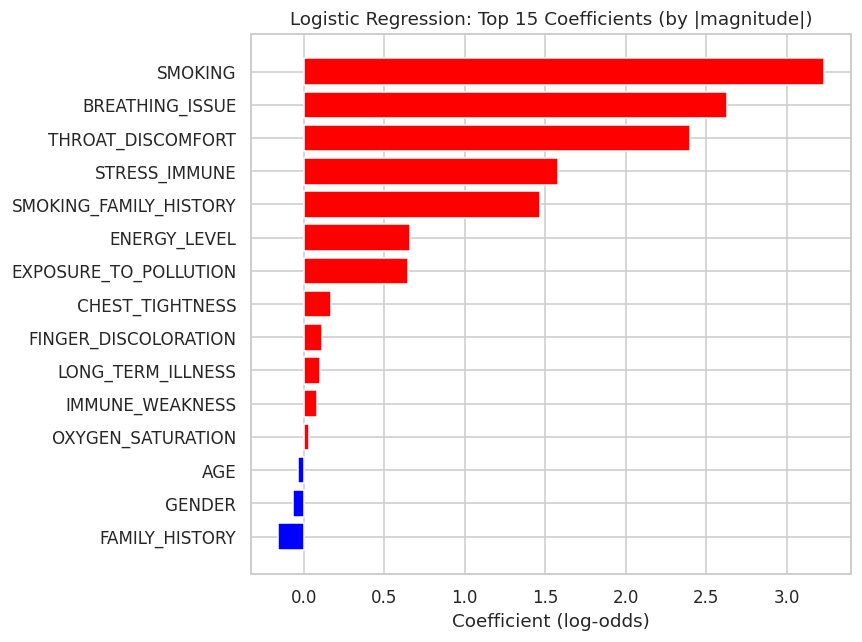

Logistic Regression — test set summary:
  Model: Logistic Regression
  Test_Recall: 0.9705882352941176
  Test_Precision: 0.5210526315789473
  Test_F1: 0.678082191780822
  Test_ROC_AUC: 0.933227344992051
  Test_PR_AUC: 0.9037627718053872
  CV_ROC_AUC_mean: 0.9251283321821339
  CV_ROC_AUC_std: 0.008053249661176725
  CV_Recall_mean: 0.915068410656646


In [9]:
def evaluate_on_test(model, X_test_scaled, y_test, threshold, model_name):
    y_prob_test = model.predict_proba(X_test_scaled)[:, 1]
    y_pred_test = (y_prob_test >= threshold).astype(int)

    result = {
        "Model": model_name,
        "Test_Recall": recall_score(y_test, y_pred_test, zero_division=0),
        "Test_Precision": precision_score(y_test, y_pred_test, zero_division=0),
        "Test_F1": f1_score(y_test, y_pred_test, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, y_prob_test),
        "Test_PR_AUC": average_precision_score(y_test, y_prob_test),
    }
    return result, y_prob_test, y_pred_test

lr_result, lr_test_prob, lr_pred_test = evaluate_on_test(log_reg, X_test_scaled, y_test, lr_threshold, "Logistic Regression")

# Plot Confusion Matrix as a heatmap
cm = confusion_matrix(y_test, lr_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Logistic Regression: Confusion Matrix (Test Set)')
plt.grid(False) # Remove grid lines for cleaner confusion matrix
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, lr_test_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Display Classification Report
print("Logistic Regression - Classification Report (Test Set):\n")
print(classification_report(y_test, lr_pred_test, target_names=['No Disease', 'Disease']))

lr_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lr_cv_roc = cross_val_score(log_reg, scale_continuous(X), y, cv=lr_cv, scoring="roc_auc")
lr_cv_rec = cross_val_score(log_reg, scale_continuous(X), y, cv=lr_cv, scoring="recall")
lr_result["CV_ROC_AUC_mean"] = lr_cv_roc.mean()
lr_result["CV_ROC_AUC_std"] = lr_cv_roc.std()
lr_result["CV_Recall_mean"] = lr_cv_rec.mean()

lr_coefs = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top15 = lr_coefs.head(15).sort_values("Coefficient")
colors = ["red" if c > 0 else "blue" for c in top15["Coefficient"]]
ax.barh(top15["Feature"], top15["Coefficient"], color=colors)
ax.set_title("Logistic Regression: Top 15 Coefficients (by |magnitude|)")
ax.set_xlabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

print("Logistic Regression — test set summary:")
for k, v in lr_result.items():
    print(f"  {k}: {v}")

In [10]:
### Model2- Random Forest ###_____________________________

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", None],
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring="recall",
    random_state=SEED,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)
rf_best = random_search.best_estimator_

print("Best Random Forest hyperparameters:")
print(random_search.best_params_)


Best Random Forest hyperparameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20, 'class_weight': 'balanced'}


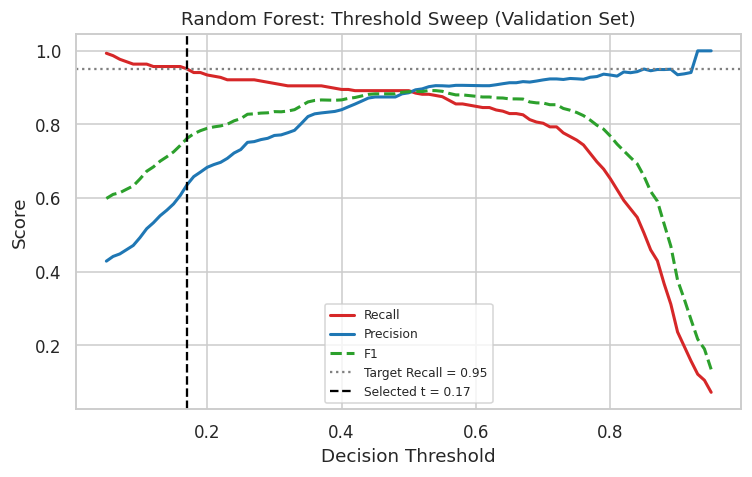

Selected threshold: 0.17  (target recall met on val: True)


In [11]:
rf_val_prob = rf_best.predict_proba(X_val)[:, 1]
rf_sweep = sweep_thresholds(y_val, rf_val_prob)
rf_threshold, rf_met_target = select_threshold(rf_sweep)
plot_sweep(rf_sweep, rf_threshold, "Random Forest")
print(f"Selected threshold: {rf_threshold}  (target recall met on val: {rf_met_target})")


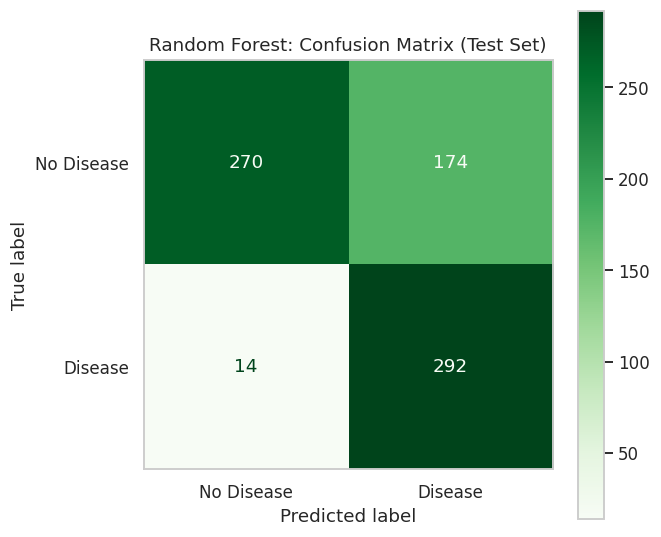

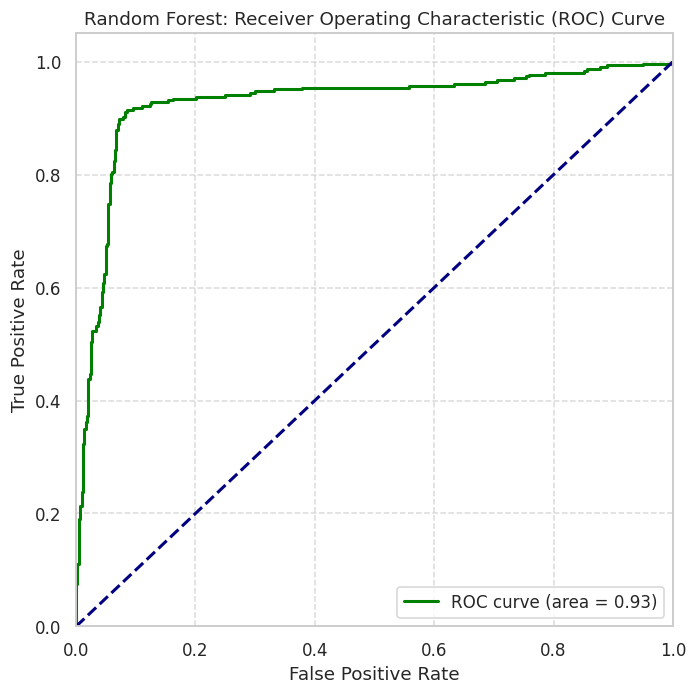

Random Forest - Classification Report (Test Set):

              precision    recall  f1-score   support

  No Disease       0.95      0.61      0.74       444
     Disease       0.63      0.95      0.76       306

    accuracy                           0.75       750
   macro avg       0.79      0.78      0.75       750
weighted avg       0.82      0.75      0.75       750



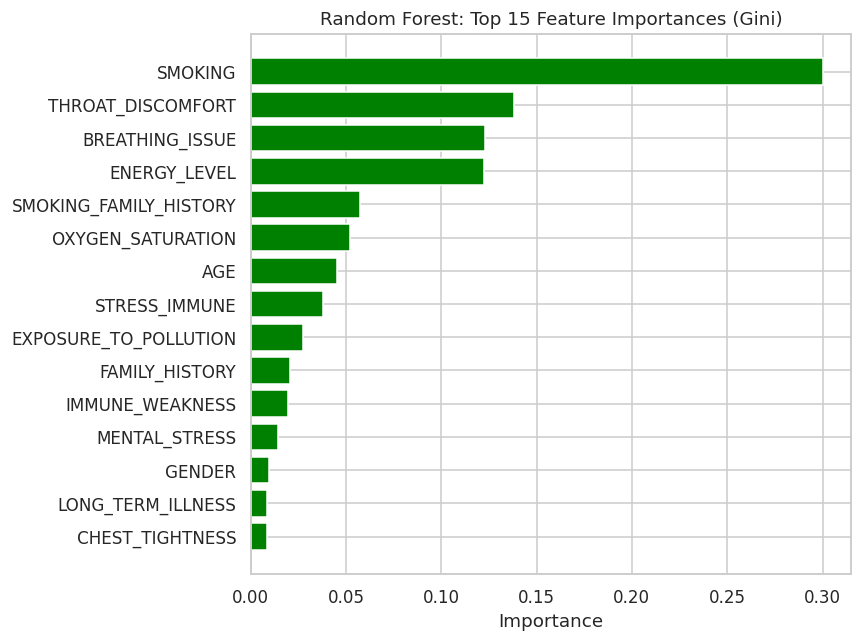

Random Forest — test set summary:
  Model: Random Forest
  Test_Recall: 0.954248366013072
  Test_Precision: 0.6266094420600858
  Test_F1: 0.7564766839378239
  Test_ROC_AUC: 0.9281634575752223
  Test_PR_AUC: 0.9024314530669617
  CV_ROC_AUC_mean: 0.9238653725310245
  CV_ROC_AUC_std: 0.005441311401403309
  CV_Recall_mean: 0.8856229223876284


In [12]:
rf_result, rf_test_prob, rf_pred_test = evaluate_on_test(rf_best, X_test, y_test, rf_threshold, "Random Forest")

# Plot Confusion Matrix as a heatmap for Random Forest
cm_rf = confusion_matrix(y_test, rf_pred_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Disease', 'Disease'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_rf.plot(cmap=plt.cm.Greens, ax=ax)
plt.title('Random Forest: Confusion Matrix (Test Set)')
plt.grid(False)
plt.show()


# Plot ROC Curve for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_test_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fig, ax = plt.subplots(figsize=(7, 7))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Display Classification Report for Random Forest
print("Random Forest - Classification Report (Test Set):\n")
print(classification_report(y_test, rf_pred_test, target_names=['No Disease', 'Disease']))

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rf_cv_roc = cross_val_score(rf_best, X, y, cv=rf_cv, scoring="roc_auc")
rf_cv_rec = cross_val_score(rf_best, X, y, cv=rf_cv, scoring="recall")
rf_result["CV_ROC_AUC_mean"] = rf_cv_roc.mean()
rf_result["CV_ROC_AUC_std"] = rf_cv_roc.std()
rf_result["CV_Recall_mean"] = rf_cv_rec.mean()

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_best.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top15 = rf_importance.head(15).sort_values("Importance")
ax.barh(top15["Feature"], top15["Importance"], color="green")
ax.set_title("Random Forest: Top 15 Feature Importances (Gini)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Random Forest — test set summary:")
for k, v in rf_result.items():
    print(f"  {k}: {v}")

In [13]:
### Model3- XGBoost ###_____________________

class_counts = np.bincount(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]
print(f"Negative: {class_counts[0]}  Positive: {class_counts[1]}  scale_pos_weight: {scale_pos_weight:.3f}")

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
print("XGBoost training complete.")


Negative: 2074  Positive: 1426  scale_pos_weight: 1.454
XGBoost training complete.


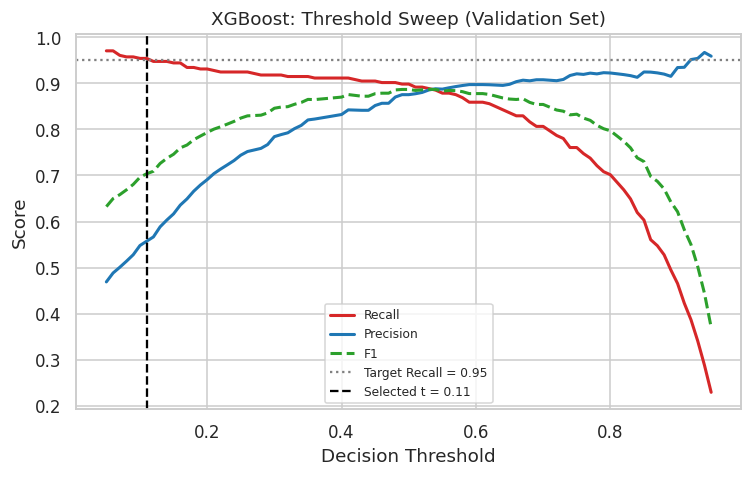

Selected threshold: 0.11  (target recall met on val: True)


In [14]:
xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_sweep = sweep_thresholds(y_val, xgb_val_prob)
xgb_threshold, xgb_met_target = select_threshold(xgb_sweep)
plot_sweep(xgb_sweep, xgb_threshold, "XGBoost")
print(f"Selected threshold: {xgb_threshold}  (target recall met on val: {xgb_met_target})")


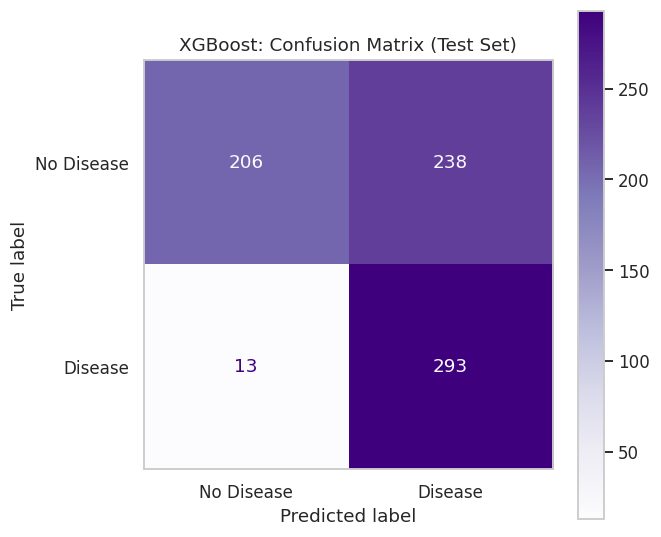

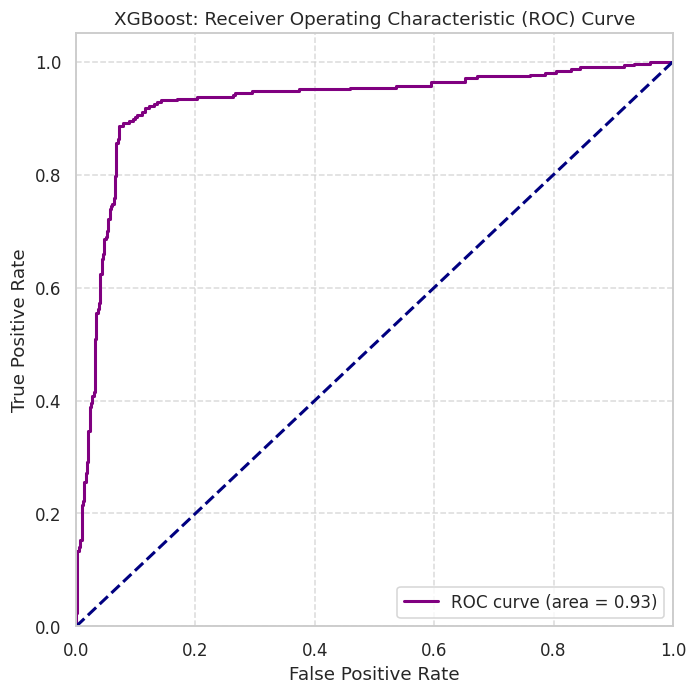

XGBoost - Classification Report (Test Set):

              precision    recall  f1-score   support

  No Disease       0.94      0.46      0.62       444
     Disease       0.55      0.96      0.70       306

    accuracy                           0.67       750
   macro avg       0.75      0.71      0.66       750
weighted avg       0.78      0.67      0.65       750



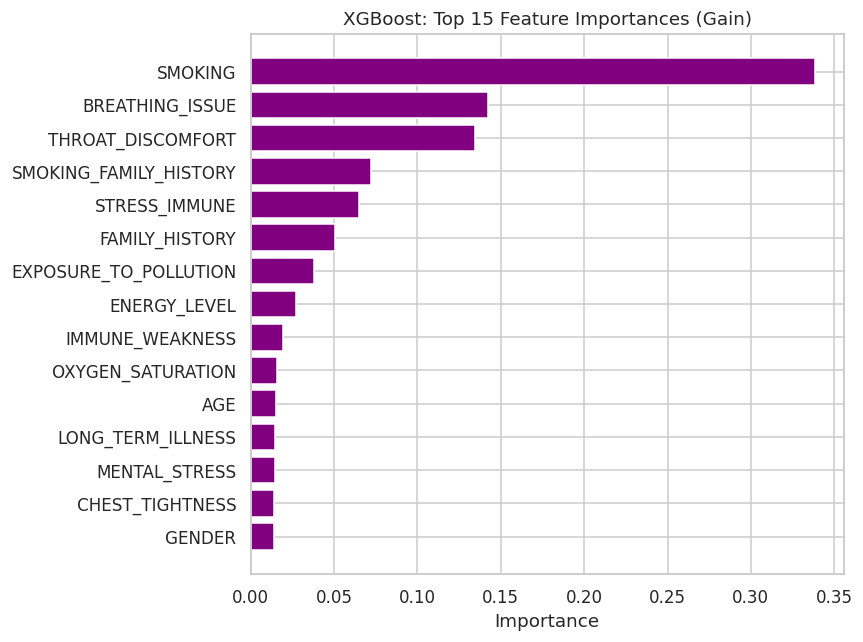

XGBoost — test set summary:
  Model: XGBoost
  Test_Recall: 0.9575163398692811
  Test_Precision: 0.551789077212806
  Test_F1: 0.7001194743130227
  Test_ROC_AUC: 0.9263896249190366
  Test_PR_AUC: 0.8906916567840844
  CV_ROC_AUC_mean: 0.9214795194246017
  CV_ROC_AUC_std: 0.00709722239412456
  CV_Recall_mean: 0.8910247145541262


In [15]:
xgb_result, xgb_test_prob, xgb_pred_test = evaluate_on_test(xgb_model, X_test, y_test, xgb_threshold, "XGBoost")

# Plot Confusion Matrix as a heatmap for XGBoost
cm_xgb = confusion_matrix(y_test, xgb_pred_test)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Disease', 'Disease'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_xgb.plot(cmap=plt.cm.Purples, ax=ax)
plt.title('XGBoost: Confusion Matrix (Test Set)')
plt.grid(False)
plt.show()


# Plot ROC Curve for XGBoost
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, xgb_test_prob)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fig, ax = plt.subplots(figsize=(7, 7))
plt.plot(fpr_xgb, tpr_xgb, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Display Classification Report for XGBoost
print("XGBoost - Classification Report (Test Set):\n")
print(classification_report(y_test, xgb_pred_test, target_names=['No Disease', 'Disease']))

xgb_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
xgb_cv_roc = cross_val_score(xgb_model, X, y, cv=xgb_cv, scoring="roc_auc")
xgb_cv_rec = cross_val_score(xgb_model, X, y, cv=xgb_cv, scoring="recall")
xgb_result["CV_ROC_AUC_mean"] = xgb_cv_roc.mean()
xgb_result["CV_ROC_AUC_std"] = xgb_cv_roc.std()
xgb_result["CV_Recall_mean"] = xgb_cv_rec.mean()

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top15 = xgb_importance.head(15).sort_values("Importance")
ax.barh(top15["Feature"], top15["Importance"], color="purple")
ax.set_title("XGBoost: Top 15 Feature Importances (Gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("XGBoost — test set summary:")
for k, v in xgb_result.items():
    print(f"  {k}: {v}")

In [17]:
### Cross-Model Comparison ###_______________________

# Add 'Selected_Threshold', 'Test_FN', and 'Test_FP' to the result dictionaries
lr_result["Selected_Threshold"] = lr_threshold
lr_result["Test_FN"] = cm[1, 0] # False Negatives from Logistic Regression confusion matrix
lr_result["Test_FP"] = cm[0, 1] # False Positives from Logistic Regression confusion matrix

rf_result["Selected_Threshold"] = rf_threshold
rf_result["Test_FN"] = cm_rf[1, 0] # False Negatives from Random Forest confusion matrix
rf_result["Test_FP"] = cm_rf[0, 1] # False Positives from Random Forest confusion matrix

xgb_result["Selected_Threshold"] = xgb_threshold
xgb_result["Test_FN"] = cm_xgb[1, 0] # False Negatives from XGBoost confusion matrix
xgb_result["Test_FP"] = cm_xgb[0, 1] # False Positives from XGBoost confusion matrix

comparison_df = pd.DataFrame([lr_result, rf_result, xgb_result])
metric_cols = ["Model", "Selected_Threshold", "Test_Recall", "Test_Precision", "Test_F1",
               "Test_ROC_AUC", "Test_PR_AUC", "CV_ROC_AUC_mean", "CV_ROC_AUC_std",
               "Test_FN", "Test_FP"]
comparison_df = comparison_df[metric_cols].round(4)

baseline_row = pd.DataFrame([{
    "Model": "Baseline (DummyClassifier)",
    "Selected_Threshold": np.nan,
    "Test_Recall": round(baseline_summary["Test_Recall"], 4),
    "Test_Precision": round(baseline_summary["Test_Precision"], 4),
    "Test_F1": round(baseline_summary["Test_F1"], 4),
    "Test_ROC_AUC": round(baseline_summary["Test_ROC_AUC"], 4),
    "Test_PR_AUC": round(baseline_summary["Test_PR_AUC"], 4),
    "CV_ROC_AUC_mean": np.nan, "CV_ROC_AUC_std": np.nan,
    "Test_FN": np.nan, "Test_FP": np.nan,
}])

full_comparison_df = pd.concat([baseline_row, comparison_df], ignore_index=True)
print(full_comparison_df.to_string(index=False))

                     Model  Selected_Threshold  Test_Recall  Test_Precision  Test_F1  Test_ROC_AUC  Test_PR_AUC  CV_ROC_AUC_mean  CV_ROC_AUC_std  Test_FN  Test_FP
Baseline (DummyClassifier)                 NaN       0.0000          0.0000   0.0000        0.5000       0.4080              NaN             NaN      NaN      NaN
       Logistic Regression                0.11       0.9706          0.5211   0.6781        0.9332       0.9038           0.9251          0.0081      9.0    273.0
             Random Forest                0.17       0.9542          0.6266   0.7565        0.9282       0.9024           0.9239          0.0054     14.0    174.0
                   XGBoost                0.11       0.9575          0.5518   0.7001        0.9264       0.8907           0.9215          0.0071     13.0    238.0


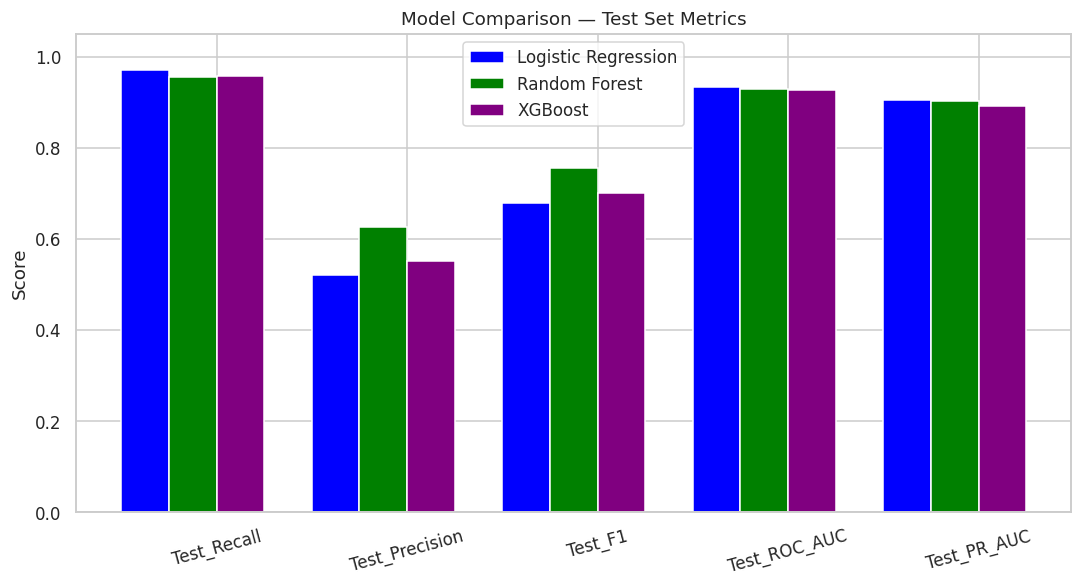

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))
metrics_to_plot = ["Test_Recall", "Test_Precision", "Test_F1", "Test_ROC_AUC", "Test_PR_AUC"]
plot_df = comparison_df.set_index("Model")[metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.25
colors = {"Logistic Regression": "blue", "Random Forest": "green", "XGBoost": "purple", "FT-Transformer": "orange"}

for i, model_name in enumerate(plot_df.index):
    ax.bar(x + i * width, plot_df.loc[model_name], width, label=model_name, color=colors[model_name])

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Test Set Metrics")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

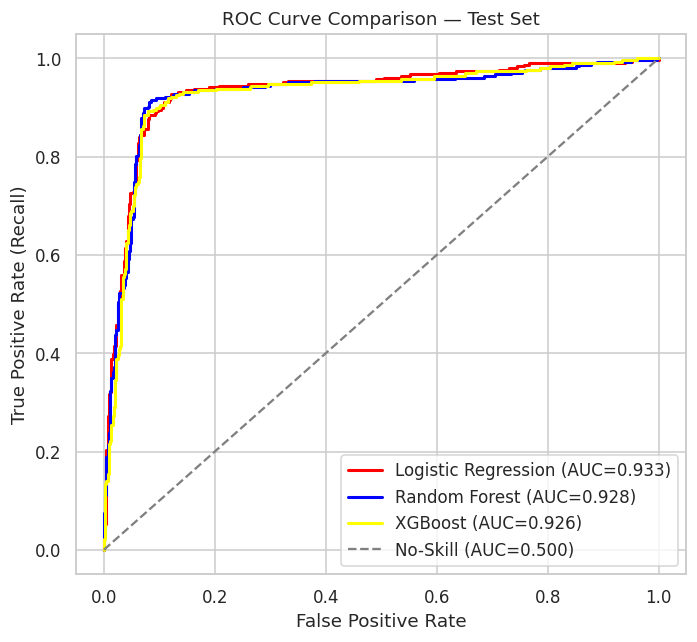

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, prob, color in [
    ("Logistic Regression", lr_test_prob, "red"),
    ("Random Forest", rf_test_prob, "blue"),
    ("XGBoost", xgb_test_prob, "yellow"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="No-Skill (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve Comparison — Test Set")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
#### Statistical Significance of ROC-AUC Differences (Bootstrap, n=1000)


def bootstrap_auc_diff(y_true, prob_a, prob_b, n_boot=1000, seed=SEED):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    diffs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(set(y_true[idx])) < 2:
            continue
        auc_a = roc_auc_score(y_true[idx], prob_a[idx])
        auc_b = roc_auc_score(y_true[idx], prob_b[idx])
        diffs.append(auc_a - auc_b)
    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), ci_low, ci_high

y_test_arr = y_test.values
pairs = [
    ("Random Forest", rf_test_prob, "Logistic Regression", lr_test_prob),
    ("XGBoost", xgb_test_prob, "Logistic Regression", lr_test_prob),
    ("XGBoost", xgb_test_prob, "Random Forest", rf_test_prob),
]

print("Bootstrap 95% CI on ROC-AUC difference (A - B); CI excluding 0 = significant at alpha=0.05\n")
for name_a, prob_a, name_b, prob_b in pairs:
    mean_diff, lo, hi = bootstrap_auc_diff(y_test_arr, prob_a, prob_b)
    significant = not (lo <= 0 <= hi)
    print(f"  {name_a} - {name_b}: mean diff = {mean_diff:+.4f}, 95% CI = [{lo:+.4f}, {hi:+.4f}]  "
          f"{'SIGNIFICANT' if significant else 'not significant'}")



Bootstrap 95% CI on ROC-AUC difference (A - B); CI excluding 0 = significant at alpha=0.05

  Random Forest - Logistic Regression: mean diff = -0.0052, 95% CI = [-0.0159, +0.0052]  not significant
  XGBoost - Logistic Regression: mean diff = -0.0069, 95% CI = [-0.0142, -0.0000]  SIGNIFICANT
  XGBoost - Random Forest: mean diff = -0.0017, 95% CI = [-0.0093, +0.0062]  not significant


In [23]:
### BEST MODEL ###_______________________________


print("=" * 70)
print("BEST MODEL SELECTION")
print("=" * 70)
print("Primary criterion: Test Recall (clinical cost of false negatives is highest).")
print("Tie-break criteria: Precision, then ROC-AUC.\n")

ranked = comparison_df.sort_values(
    by=["Test_Recall", "Test_Precision", "Test_ROC_AUC"], ascending=False
).reset_index(drop=True)
print(ranked[["Model", "Test_Recall", "Test_Precision", "Test_F1", "Test_ROC_AUC", "Test_PR_AUC"]].to_string(index=False))

best_model_name = ranked.iloc[0]["Model"]
print(f"\nSelected best classical ML model: {best_model_name}")
print(f"  Test Recall    : {ranked.iloc[0]['Test_Recall']:.3f}")
print(f"  Test Precision : {ranked.iloc[0]['Test_Precision']:.3f}")
print(f"  Test ROC-AUC   : {ranked.iloc[0]['Test_ROC_AUC']:.3f}")


BEST MODEL SELECTION
Primary criterion: Test Recall (clinical cost of false negatives is highest).
Tie-break criteria: Precision, then ROC-AUC.

              Model  Test_Recall  Test_Precision  Test_F1  Test_ROC_AUC  Test_PR_AUC
Logistic Regression       0.9706          0.5211   0.6781        0.9332       0.9038
            XGBoost       0.9575          0.5518   0.7001        0.9264       0.8907
      Random Forest       0.9542          0.6266   0.7565        0.9282       0.9024

Selected best classical ML model: Logistic Regression
  Test Recall    : 0.971
  Test Precision : 0.521
  Test ROC-AUC   : 0.933


In [24]:
### Shared Parameters Reference


shared_params = pd.DataFrame([
    ("Random seed", SEED),
    ("Train / Val / Test split", "70% / 15% / 15%, stratified"),
    ("Split method", "Single canonical split reused by all 3 models"),
    ("Scaling", "StandardScaler on continuous features, fit on train only (LR only)"),
    ("Class imbalance handling — LR", "class_weight='balanced'"),
    ("Class imbalance handling — RF", "Tuned via RandomizedSearchCV over ['balanced', None]"),
    ("Class imbalance handling — XGBoost", "scale_pos_weight computed from y_train"),
    ("Threshold selection", "Swept 0.05-0.95 on validation set; highest-precision threshold with Recall >= 0.95"),
    ("Baseline", "DummyClassifier (most_frequent)"),
    ("Cross-validation", "5-fold stratified, scoring = ROC-AUC and Recall"),
], columns=["Parameter", "Value"])

print(shared_params.to_string(index=False))


                         Parameter                                                                              Value
                       Random seed                                                                                 42
          Train / Val / Test split                                                        70% / 15% / 15%, stratified
                      Split method                                      Single canonical split reused by all 3 models
                           Scaling                 StandardScaler on continuous features, fit on train only (LR only)
     Class imbalance handling — LR                                                            class_weight='balanced'
     Class imbalance handling — RF                               Tuned via RandomizedSearchCV over ['balanced', None]
Class imbalance handling — XGBoost                                             scale_pos_weight computed from y_train
               Threshold selection Swept 0.05-0.95 on va